<a href="https://colab.research.google.com/github/thanh-huy/SIC_Excercies/blob/main/69_ex_0701.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Coding Exercise #0701

### 1. Convolutional Neural Network(MNIST):

In [21]:
import tensorflow as tf
print(tf.__version__)
import matplotlib.pyplot as plt


2.20.0


In [2]:
# Install tensorflow_datasets.
!pip install tensorflow_datasets

In [4]:
pip install --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.


In [7]:
pip install importlib_resources

In [8]:
import tensorflow_datasets as tfds
import numpy as np

In [9]:
# Hyperparameter definitions.
BUFFER_SIZE = 10000
BATCH_SIZE = 64
NUM_EPOCHS = 20

In [10]:
# Calculate the number of steps per epoch (60,000 images total).
steps_per_epoch = int(np.ceil(60000 / BATCH_SIZE))
print(steps_per_epoch)

938


In [11]:
# Load MNIST dataset.
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.0IRECX_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.0IRECX_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [12]:
# Preprocessing function.
def preprocess(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image, label

In [14]:
# Build input pipeline.
# Training dataset
train_ds = (
    ds_train
    .map(preprocess)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset.
test_ds = (
    ds_test
    .map(preprocess)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [20]:
# Define the DNN classifier model.
dnn_classifier = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model.
dnn_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
dnn_classifier.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model and save the training history.
history = dnn_classifier.fit(
    train_ds,
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_ds
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8804 - loss: 0.4185 - val_accuracy: 0.9386 - val_loss: 0.2192
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9408 - loss: 0.2068 - val_accuracy: 0.9482 - val_loss: 0.1786
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9514 - loss: 0.1688 - val_accuracy: 0.9531 - val_loss: 0.1654
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9581 - loss: 0.1439 - val_accuracy: 0.9575 - val_loss: 0.1422
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9622 - loss: 0.1275 - val_accuracy: 0.9601 - val_loss: 0.1321
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9669 - loss: 0.1137 - val_accuracy: 0.9622 - val_loss: 0.1224
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9703 - loss: 0.1015 - val_accuracy: 0.9647 - val_loss: 0.1192
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9712 - loss: 0.0957 - val_accuracy: 0

In [18]:
# Evaluate the model.
eval_loss, eval_acc = dnn_classifier.evaluate(test_ds)
print("Evaluation loss:", eval_loss)
print("Evaluation accuracy:", eval_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9639 - loss: 0.1393
Evaluation loss: 0.13926933705806732
Evaluation accuracy: 0.9639000296592712


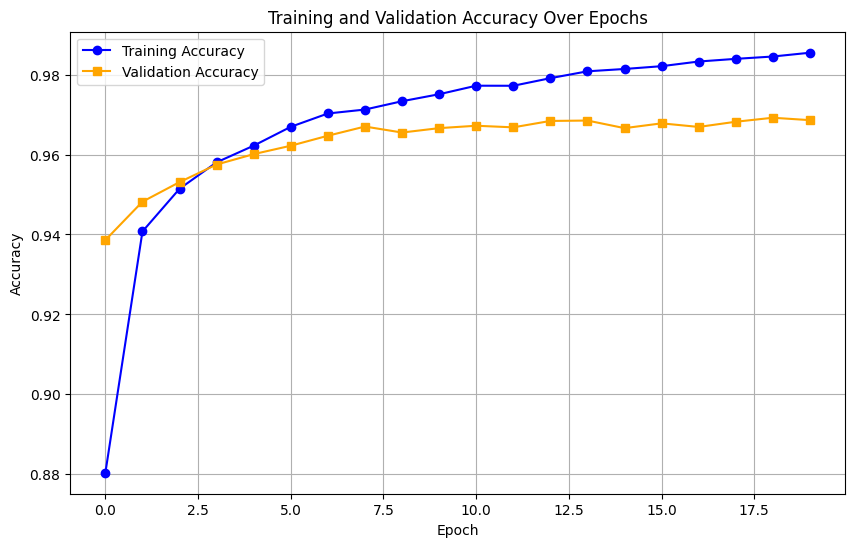

In [25]:
# Access history from the saved variable to plot accuracy and validation accuracy
history_dict = history.history

plt.figure(figsize=(10, 6))
plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='orange', marker='s')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_skips = 0